In [1]:
# Setup and Data Ingestion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print(" INITIALIZING ML ENGINE FOR ORYZA SATIVA (RICE)...")

# 1. Load the clean, normalized data from Phase 1
file_path = "C:\\Users\\kumar\\Desktop\\CrossKingdom_Biomarker_Project\\01_Data\\Processed_Data\\Rice_Cleaned_Normalized.csv"
rice_clean_df = pd.read_csv(file_path, index_col=0)

# 2. Separate the Features (Genes/X) from the Target (Condition/y)
# 'Heat_Stress_Target' is the column we added in the last notebook
X_rice = rice_clean_df.drop('Heat_Stress_Target', axis=1)
y_rice = rice_clean_df['Heat_Stress_Target']

print(f" Clean Data Loaded! Ready to process {X_rice.shape[1]:,} genes across {X_rice.shape[0]} samples.")

 INITIALIZING ML ENGINE FOR ORYZA SATIVA (RICE)...
 Clean Data Loaded! Ready to process 13,195 genes across 6 samples.


In [2]:
# Building and Training the Model
print(" TRAINING RANDOM FOREST CLASSIFIER...")

# Initialize the architecture 
rf_engine_rice = RandomForestClassifier(
    n_estimators=500,        # 500 independent trees (Bootstrap Aggregating)
    max_features='sqrt',     # Random Subspace Method (Crucial for p >> n)
    oob_score=True,          # Internal validation
    random_state=42,         # Ensures reproducible results 
    n_jobs=-1                # Uses all available laptop CPU cores for speed
)

# Train the model on the data
rf_engine_rice.fit(X_rice, y_rice)

print(" Training Complete!")
print(f"Out-of-Bag (OOB) Accuracy Score: {rf_engine_rice.oob_score_ * 100:.2f}%")

 TRAINING RANDOM FOREST CLASSIFIER...
 Training Complete!
Out-of-Bag (OOB) Accuracy Score: 100.00%


 EXTRACTING TOP SURVIVAL BIOMARKERS...
 Ranked biomarker list safely saved to: ../04_Results/Ranked_Biomarkers/Oryza_sativa_Top_Genes.csv

 TOP 10 RICE HEAT-STRESS SURVIVAL GENES:


,Gene_ID,Gini_Importance_Score
9520,B6750,0.006160
4691,B2370,0.004107
3106,B12825,0.004107
3046,B12771,0.004107
5765,B3344,0.004107
2008,B11830,0.004107
1605,B11464,0.004107
9406,B6645,0.004107
13073,B9979,0.004107
699,B10633,0.002053


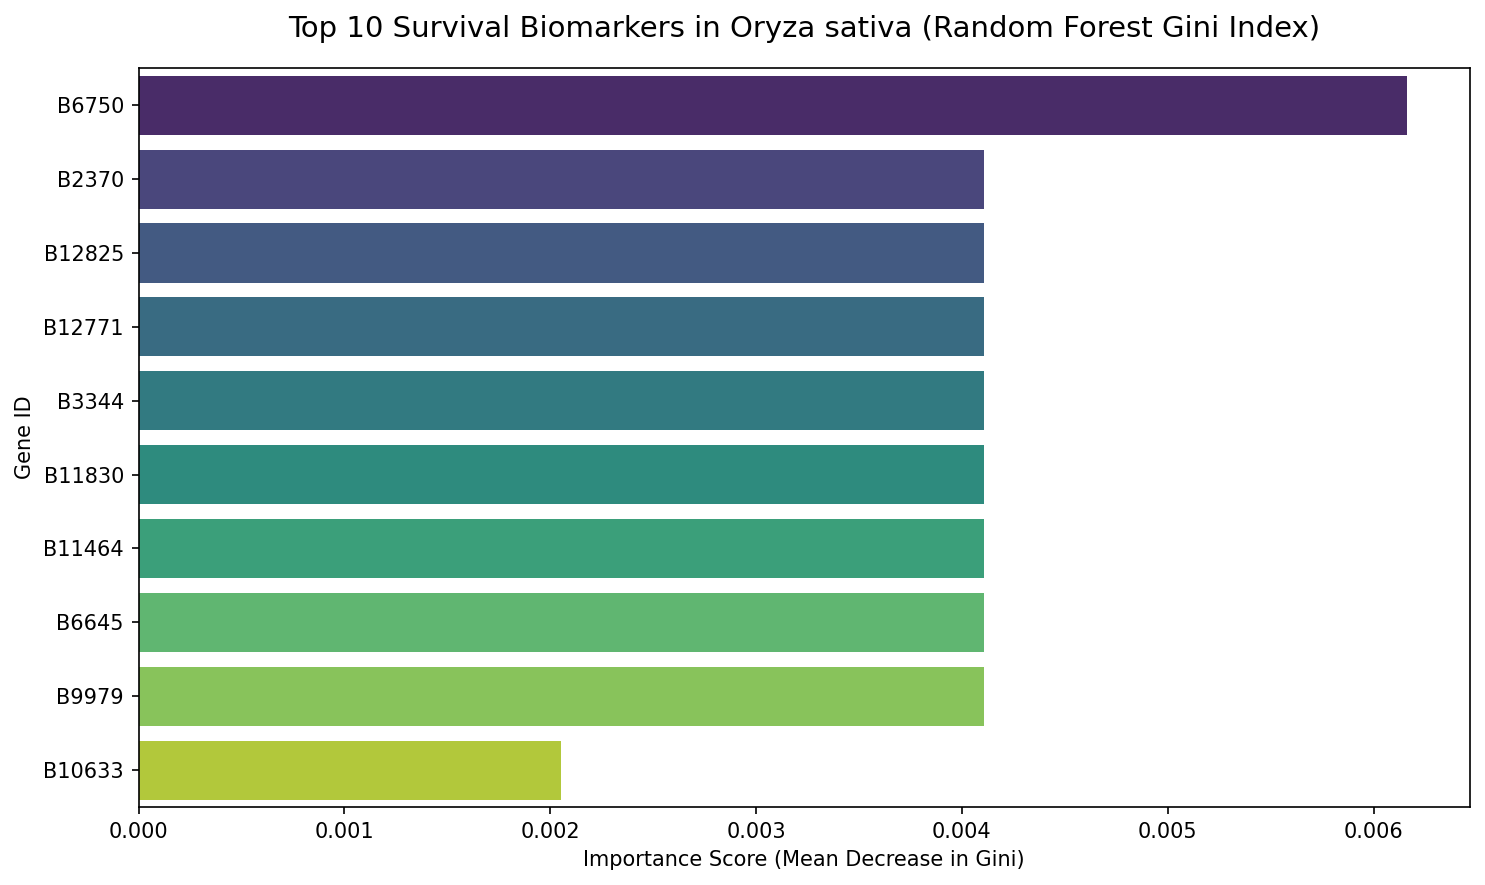

In [5]:
# Biomarker Extraction and Visualization
import os

print(" EXTRACTING TOP SURVIVAL BIOMARKERS...")

# 1. Get the Gini Importance scores from the trained model
gini_scores = rf_engine_rice.feature_importances_

# 2. Create a DataFrame to rank the genes
biomarkers_rice = pd.DataFrame({
    'Gene_ID': X_rice.columns,
    'Gini_Importance_Score': gini_scores
})

# 3. Sort from most important to least important
top_rice_genes = biomarkers_rice.sort_values(by='Gini_Importance_Score', ascending=False)

# 4. Ensure output directories exist, then save the full ranked list
os.makedirs("../04_Results/Ranked_Biomarkers", exist_ok=True)
os.makedirs("../04_Results/Visualizations", exist_ok=True)

output_csv = "../04_Results/Ranked_Biomarkers/Oryza_sativa_Top_Genes.csv"
top_rice_genes.to_csv(output_csv, index=False)
print(f" Ranked biomarker list safely saved to: {output_csv}")

# 5. Display the Top 10 in the notebook
print("\n TOP 10 RICE HEAT-STRESS SURVIVAL GENES:")
display(top_rice_genes.head(10))

# 6. Generate a professional bar chart for your PPT
plt.figure(figsize=(10, 6), dpi=150)
sns.barplot(x='Gini_Importance_Score', y='Gene_ID', data=top_rice_genes.head(10), hue='Gene_ID', palette='viridis', legend=False)
plt.title("Top 10 Survival Biomarkers in Oryza sativa (Random Forest Gini Index)", fontsize=14, pad=15)
plt.xlabel("Importance Score (Mean Decrease in Gini)")
plt.ylabel("Gene ID")
plt.tight_layout()

# Save the plot
plt.savefig("../04_Results/Visualizations/Rice_Top10_Biomarkers.png")
plt.show()